# Extreme Value Analysis on the simulated Discharge / stage relationship

## 0. Importing packages

In [37]:
!pip install arviz
!pip install pymc
!pip install reliability

In [38]:
# Import necessary libraries and packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy import stats 
from scipy.optimize import curve_fit
import arviz as az
import pymc as pm
from scipy.signal import find_peaks
import reliability.Fitters as rf

## 1. Loading Data

### 1.1 Discharge Measurements processing

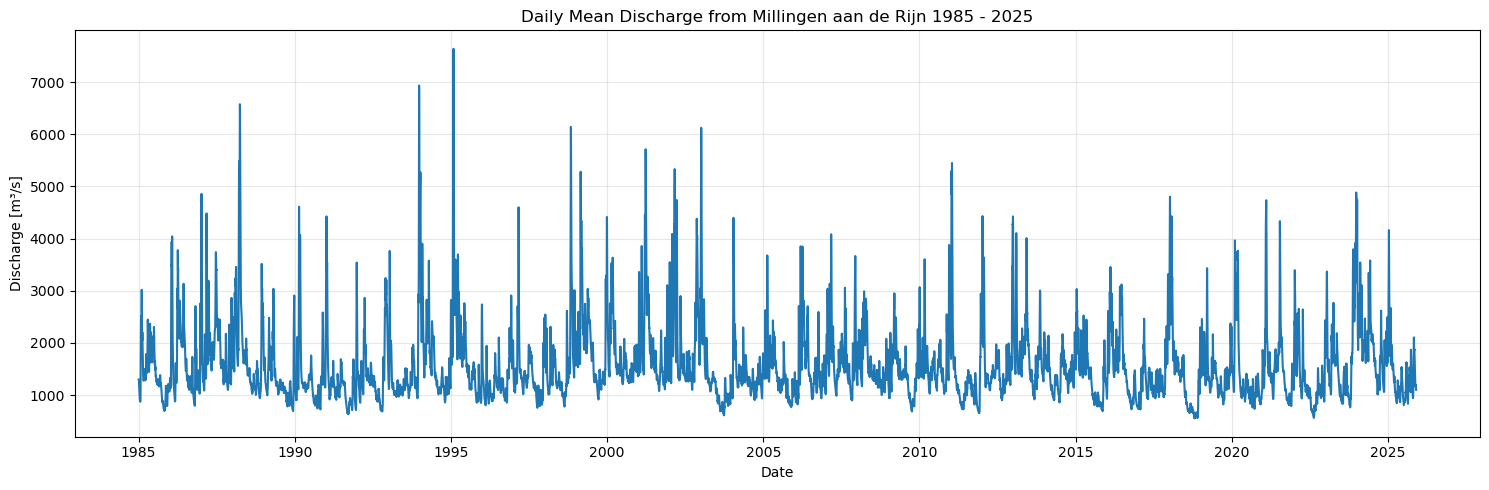

In [39]:
files = ['data/Mill1.csv', 'data/Mill2.csv', 'data/Mill3.csv', 'data/Mill4.csv']

data_frames = []

for file_name in files:
    df = pd.read_csv(file_name, sep=';', encoding="latin1")
    df["datum"] = pd.to_datetime(df["datum"], dayfirst=True)
    df["waarde"] = pd.to_numeric(df["waarde"].astype(str).str.replace(",", "."))
    df.loc[df["waarde"] > 1e5, "waarde"] = np.nan 
    df = df.dropna(subset=["datum", "waarde"]) 
    
    daily_mean = df.groupby("datum")["waarde"].mean()
    data_frames.append(daily_mean)


Q_series = pd.concat(data_frames).sort_index()
Q_series = Q_series.groupby(Q_series.index).mean() #removes overlapping dates

# Plotting
plt.figure(figsize=(15, 5))
plt.plot(Q_series.index, Q_series.values)
plt.xlabel("Date")
plt.ylabel("Discharge [m³/s]")
plt.title("Daily Mean Discharge from Millingen aan de Rijn 1985 - 2025")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 1.2 Water level data processing

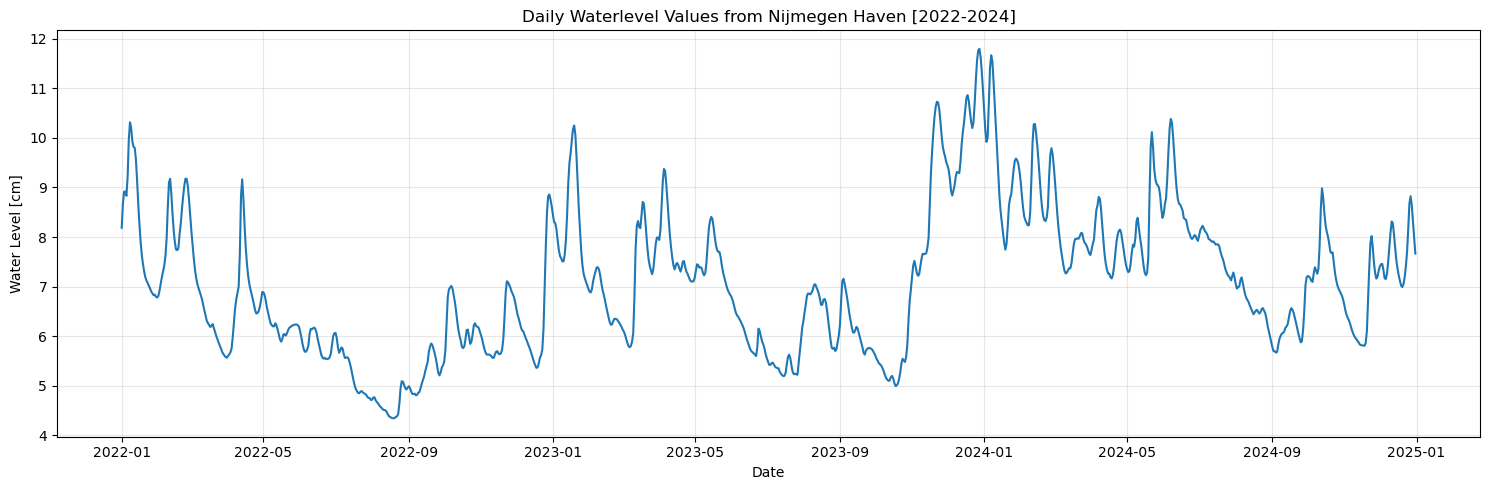

In [40]:
filename = 'data/nijmegen_haven_2022-2024.csv'

df_h = pd.read_csv(filename, sep=';', encoding="latin1")
df_h["datum"] = pd.to_datetime(df_h["WAARNEMINGDATUM"],dayfirst=True)
df_h["waarde"] = pd.to_numeric(df_h["NUMERIEKEWAARDE"].astype(str).str.replace(",", "."))
df_h.loc[df_h["waarde"] > 1e5, "waarde"] = np.nan 

df_h['waarde_meters'] = df_h['waarde'] / 100.0
df_h = df_h.dropna(subset=["datum", "waarde_meters"]) 
h_series = df_h.groupby("datum")["waarde_meters"].mean() # transform to daily mean 

# Plotting
plt.figure(figsize=(15, 5))
plt.plot(h_series.index, h_series.values)
plt.xlabel("Date")
plt.ylabel("Water Level [cm]")
plt.title(f"Daily Waterlevel Values from Nijmegen Haven [2022-2024]")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 1.3 Merging Discharge and water level data

Total Combined Days: 1092


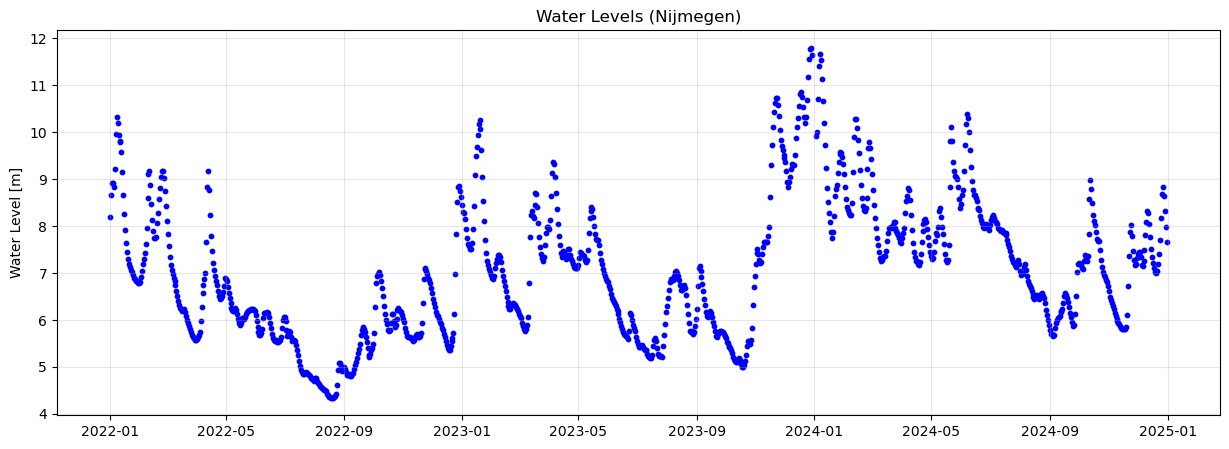

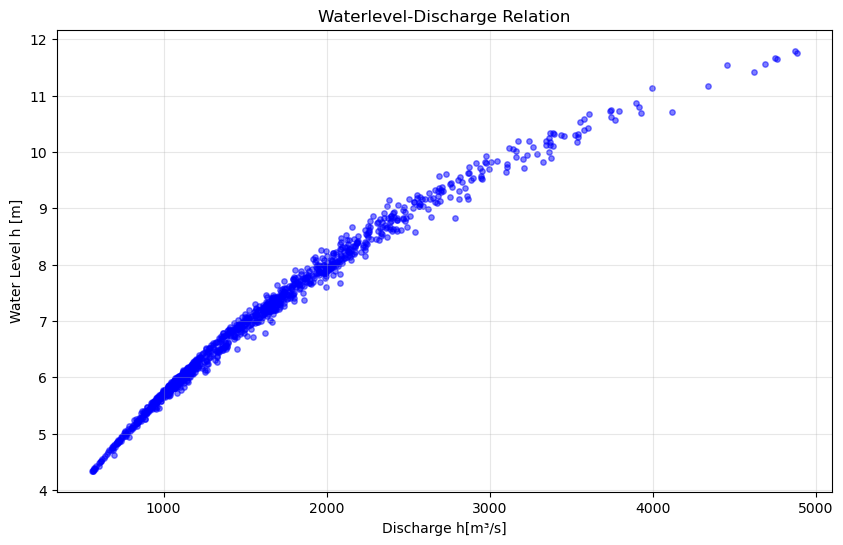

In [41]:
# Split data into training and validation sets.
combined_df = pd.concat([Q_series, h_series], axis=1, join='inner')
combined_df.columns = ['Q_m3s', 'h_meters']

print(f"Total Combined Days: {len(combined_df)}")

Q_data = combined_df['Q_m3s'].values
h_data = combined_df['h_meters'].values

plt.figure(figsize=(15, 5))
plt.scatter(combined_df.index, h_data, s=10, color='blue')
plt.title("Water Levels (Nijmegen)")
plt.ylabel("Water Level [m]")
plt.grid(True, alpha=0.3)

plt.figure(figsize=(10, 6))
plt.scatter(Q_data, h_data, s=15, alpha=0.5, color='blue')
plt.xlabel("Discharge h[m³/s]")
plt.ylabel("Water Level h [m]")
plt.title("Waterlevel-Discharge Relation")
plt.grid(True, alpha=0.3)
plt.show()

## 2. PYMC

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [log_a, log_b, h0, log_sigma]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 123 seconds.


        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
a     7.1348 1.1954  4.8914   9.4227       0.03   0.0216   1570.84   1759.96 1.0039
b     2.5114 0.0533  2.4133   2.6142     0.0013    0.001   1576.34   1797.58 1.0041
h0    -1.494 0.1865 -1.8383   -1.137     0.0047   0.0035   1572.24   1770.07 1.0043
sigma  0.113 0.0024  0.1083   0.1174          0        0   2406.93   2198.15 1.0012


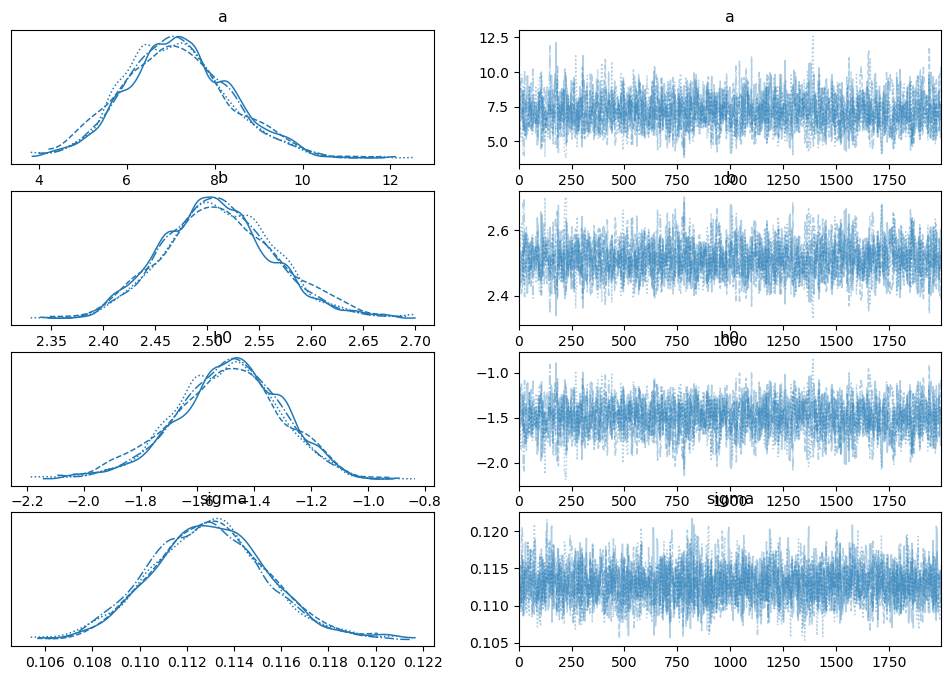

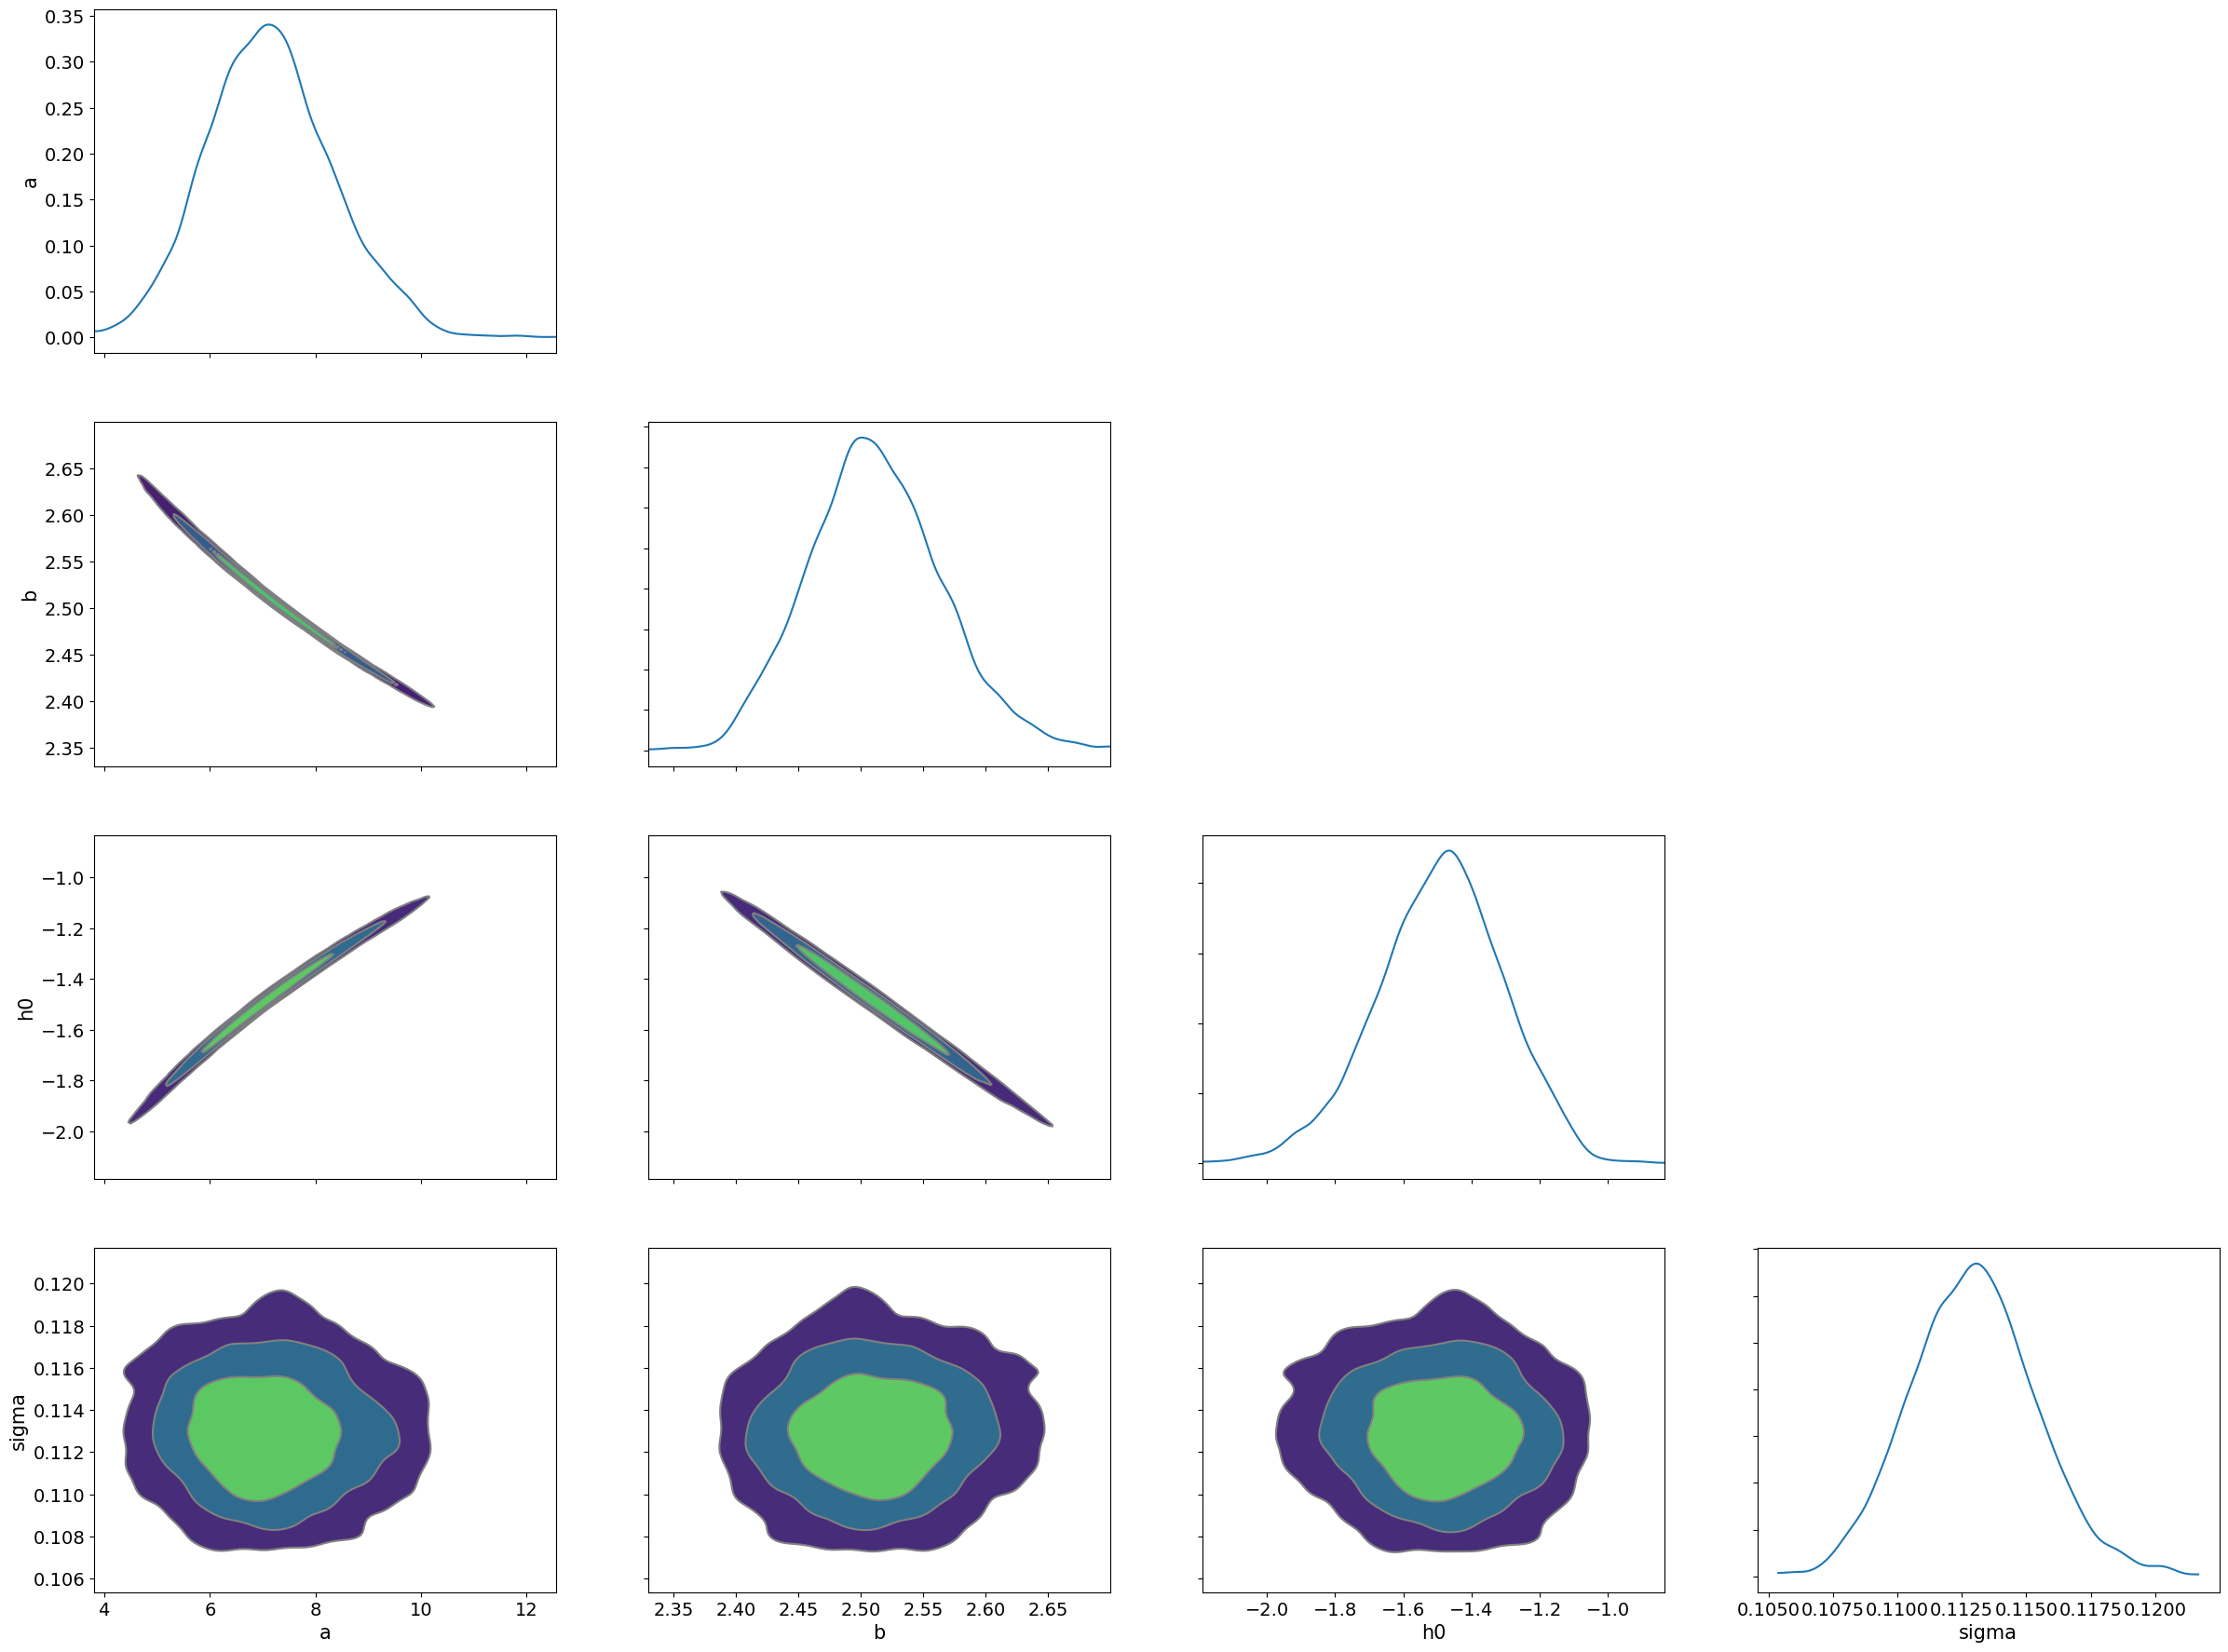

Sampling: [h_obs]


Output()

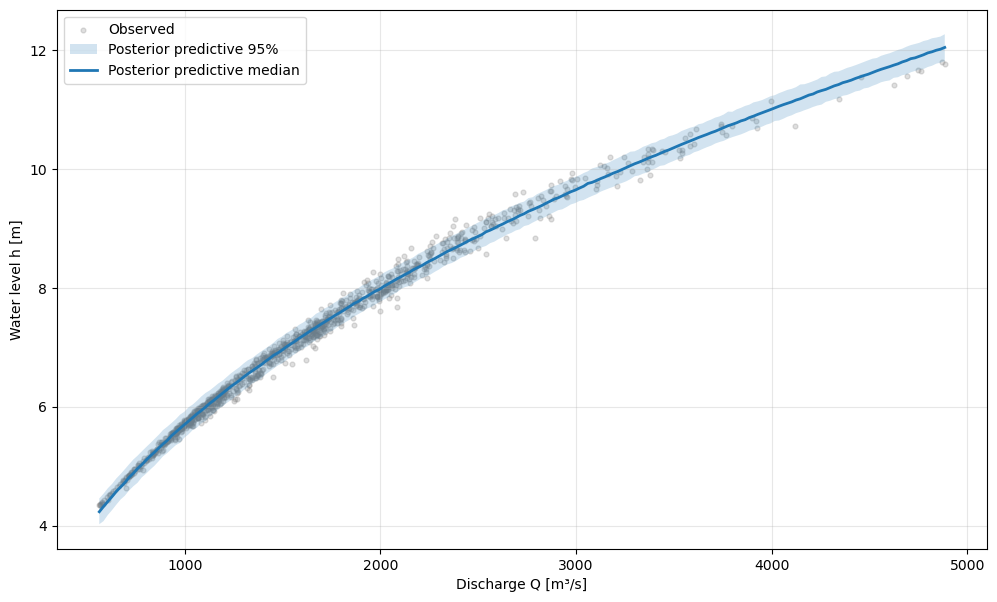

In [42]:
# --- data ---
Q = Q_data.astype(float)
h = h_data.astype(float)

min_h = float(np.min(h))
Q_scale = np.median(Q)
Qn = Q / Q_scale

with pm.Model() as model:
    # Priors
    log_a = pm.Normal("log_a", mu=np.log(25), sigma=1.5)
    a = pm.Deterministic("a", pm.math.exp(log_a))

    log_b = pm.Normal("log_b", mu=np.log(2.0), sigma=0.5)
    b = pm.Deterministic("b", pm.math.exp(log_b))

    h0 = pm.Normal("h0", mu=-1.25, sigma=1.0)

    log_sigma = pm.Normal("log_sigma", mu=np.log(0.1), sigma=0.2)
    sigma = pm.Deterministic("sigma", pm.math.exp(log_sigma))

    a_scaled = pm.Deterministic("a_scaled", a / Q_scale)

    mu = h0 + (pm.math.maximum(Qn / a_scaled, 0.0)) ** (1.0 / b)

    obs = pm.Normal("h_obs", mu=mu, sigma=sigma, observed=h)

    # Sampling
    idata = pm.sample(draws=2000, tune=2000, 
        chains=4, target_accept=0.95, max_treedepth=15, random_seed=42)

print(az.summary(idata, var_names=["a", "b", "h0", "sigma"], round_to=4))
az.plot_trace(idata, var_names=["a", "b", "h0", "sigma"])
plt.show()

az.plot_pair(idata, var_names=["a", "b", "h0", "sigma"], kind="kde", marginals=True)
plt.show()

# Posterior predictive (this includes parameter uncertainty + observation noise)
with model:
    ppc = pm.sample_posterior_predictive(idata, var_names=["h_obs"], random_seed=42)

# Build posterior predictive band over a Q-range
Q_range = np.linspace(Q.min(), Q.max(), 200)
Qn_range = Q_range / Q_scale

# Take posterior draws for parameters
post = idata.posterior
a_s = post["a"].values.reshape(-1)
b_s = post["b"].values.reshape(-1)
h0_s = post["h0"].values.reshape(-1)
sig_s = post["sigma"].values.reshape(-1)

# simulate predictive curves
N = min(2000, a_s.size)
idx = np.random.choice(a_s.size, size=N, replace=False)

pred = np.zeros((N, Q_range.size))
for i, k in enumerate(idx):
    mu_k = h0_s[k] + np.power(np.maximum(Qn_range / (a_s[k] / Q_scale), 0.0), 1.0 / b_s[k])
    pred[i] = mu_k + np.random.normal(0.0, sig_s[k], size=Q_range.size)

lo, med, hi = np.percentile(pred, [2.5, 50, 97.5], axis=0)

plt.figure(figsize=(12, 7))
plt.scatter(Q, h, s=12, alpha=0.25, color="gray", label="Observed")
plt.fill_between(Q_range, lo, hi, alpha=0.2, label="Posterior predictive 95%")
plt.plot(Q_range, med, linewidth=2, label="Posterior predictive median")
plt.xlabel("Discharge Q [m³/s]")
plt.ylabel("Water level h [m]")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 3. Stage-Discharge model

In [43]:
def stage_discharge_model(Q, a, b, h0, sigma):
    term = np.maximum(Q / a, 0.0)
    h = h0 + np.power(term, 1.0 / b)
    return h + np.random.normal(0, sigma, size=h.shape)

In [44]:
a, b, h0, sigma = 7.1438, 2.51, -1.494, 0.113

In [45]:
Q_sim = pd.read_csv("data/discharge_sim.csv")
Q_sim = Q_sim.rename(columns={'50% confidence interval' : 'Q_sim'})


In [46]:
h_sim = stage_discharge_model(Q_sim['Q_sim'], a, b, h0, sigma)

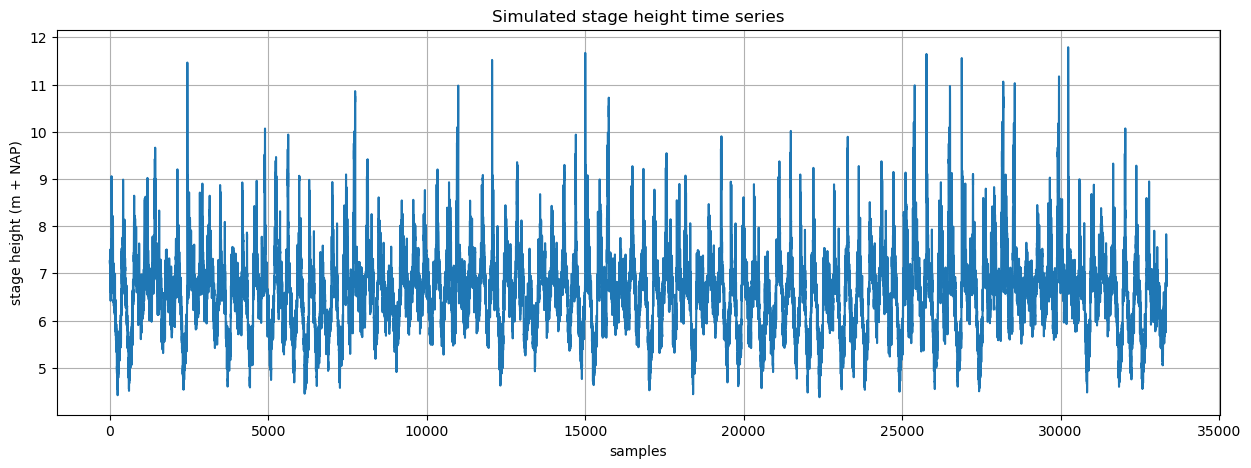

In [47]:
plt.figure(figsize=(15,5))
plt.plot(h_sim.index, h_sim)
plt.xlabel('samples')
plt.ylabel('stage height (m + NAP)')
plt.title('Simulated stage height time series')
plt.grid()

## 4. Extreme Value Analysis

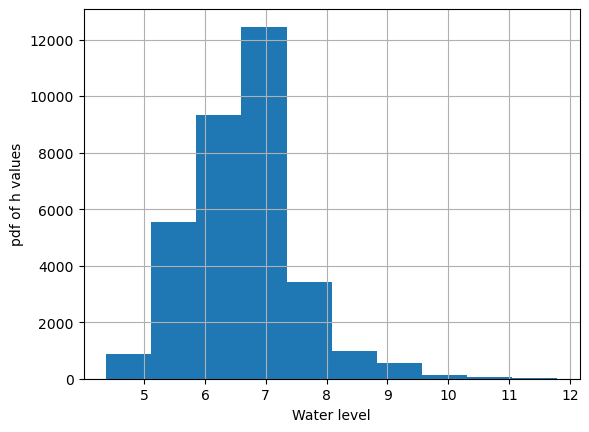

In [48]:
fig, ax = plt.subplots(1, 1)
plt.xlabel('Water level')
plt.ylabel('pdf of h values')
ax.hist(h_sim, histtype='stepfilled')
plt.grid()
plt.show()

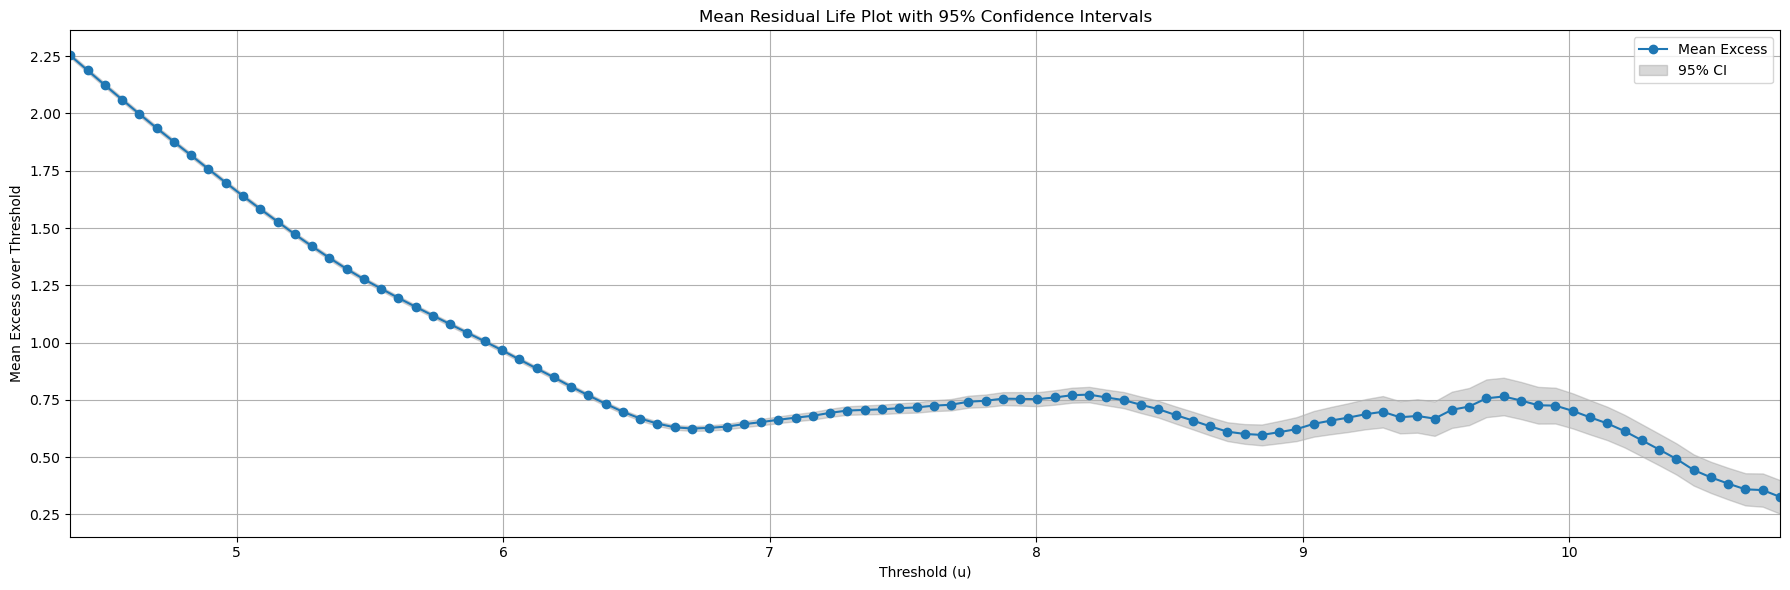

In [49]:
thresholds = np.linspace(h_sim.min(), h_sim.max() -1, 100)
mean_excess = []
ci_lower = []
ci_upper = []

for u in thresholds:
    excess = h_sim[h_sim > u] - u
    n = len(excess)
    if n > 1:
        mean = excess.mean()
        std = excess.std(ddof=1)
        se = std / np.sqrt(n)
        ci = 1.96 * se  
        mean_excess.append(mean)
        ci_lower.append(mean - ci)
        ci_upper.append(mean + ci)
    elif n == 1:
        mean_excess.append(excess.iloc[0])
        ci_lower.append(np.nan)
        ci_upper.append(np.nan)
    else:
        mean_excess.append(np.nan)
        ci_lower.append(np.nan)
        ci_upper.append(np.nan)

thr = np.asarray(thresholds)
me  = np.asarray(mean_excess)
lo  = np.asarray(ci_lower)
up  = np.asarray(ci_upper)



fig, ax = plt.subplots(figsize=(18, 6))
ax.plot(thr, me, marker='o', label='Mean Excess')
ax.fill_between(thr, lo, up, color='gray', alpha=0.3, label='95% CI')


finite = np.isfinite(me)
ax.set_xlim(thr[finite].min(), thr[finite].max()) 
ax.set_xmargin(0)                                  

ax.set_xlabel('Threshold (u)')
ax.set_ylabel('Mean Excess over Threshold')
ax.set_title('Mean Residual Life Plot with 95% Confidence Intervals')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show() 

In [50]:
def pot_method(series, threshold, min_sep_samples):
    """
    Peaks-over-threshold on a 1D series.

    series: pandas Series (any index) or 1D array
    threshold: float (min peak height)
    min_sep_samples: int (min separation in samples; e.g., 24h @ 3-hourly -> 8)
    """
    if isinstance(series, pd.Series):
        y = series.to_numpy()
    else:
        y = np.asarray(series)

    distance = max(1, int(min_sep_samples))
    idx_pos, props = find_peaks(y, height=threshold, distance=distance)

    if isinstance(series, pd.Series):
        peaks = series.iloc[idx_pos]  
    else:
        peaks = pd.Series(y[idx_pos], index=idx_pos)

    return idx_pos, peaks

threshold = 8.5 # in meters

d_time = 10 # in days

tare = threshold

indices,pot_maxima = pot_method(h_sim, threshold, dtime)

kmax = len(pot_maxima)
print("Number of peaks based on Threshold: ",threshold," meters and time ",dtime_hours, "hours is ",kmax, "peaks")


Number of peaks based on Threshold:  8.5  meters and time  240 hours is  174 peaks


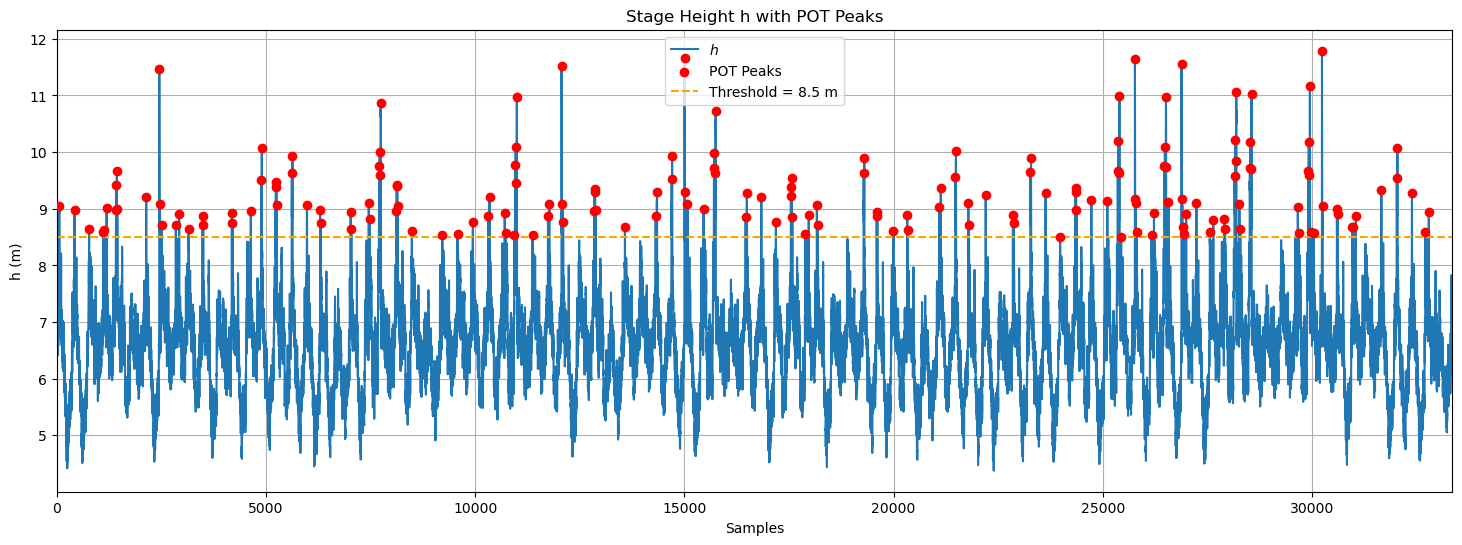

In [51]:
fig, ax = plt.subplots(figsize=(18, 6))

ax.plot(h_sim.index, h_sim,label=f'$h$')
ax.scatter(h_sim.iloc[indices].index, h_sim.iloc[indices], color='red', label='POT Peaks', zorder=10)

ax.set_xmargin(0) 
ax.set_xlabel('Samples')
ax.set_ylabel('h (m)')
ax.set_title('Stage Height h with POT Peaks')
ax.axhline(y=threshold, color='orange', linestyle='--', label=f'Threshold = {threshold} m')
ax.legend()
ax.grid()

In [52]:
dfmax = []
for it in pot_maxima.items():
    val = it[1] - tare
    dfmax.append(val)    
dfmax.sort()

/Users/tijnspijkers/miniforge3/envs/copula/lib/python3.13/site-packages/reliability/Fitters.py:440: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat(


Results from Fit_Everything:
Analysis method: MLE
Failures / Right censored: 174/0 (0% right censored) 

   Distribution    Alpha    Beta      Gamma  Alpha 1  Beta 1 Alpha 2  Beta 2 Proportion 1 DS        Mu    Sigma  Lambda  Log-likelihood    AICc     BIC       AD optimizer
 Exponential_1P                                                                                                 1.23078        -137.869 277.761 280.897  1.46333       TNC
     Weibull_2P 0.850091 1.13262                                                                                               -135.769 275.607 281.855  0.52353       TNC
       Gamma_2P 0.664428 1.22284                                                                                               -135.791 275.653 281.901 0.503286       TNC
     Weibull_CR                             0.859039 1.09997 3.20643 35.3592                                                   -131.568 271.373 283.772 0.592137       TNC
 Exponential_2P                  0.00359

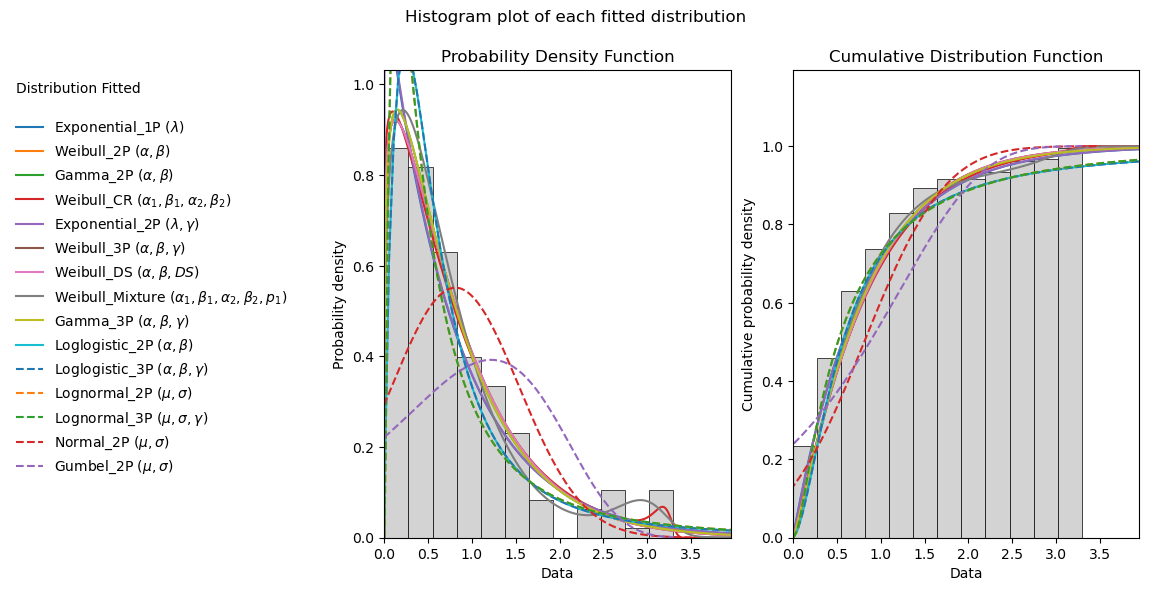

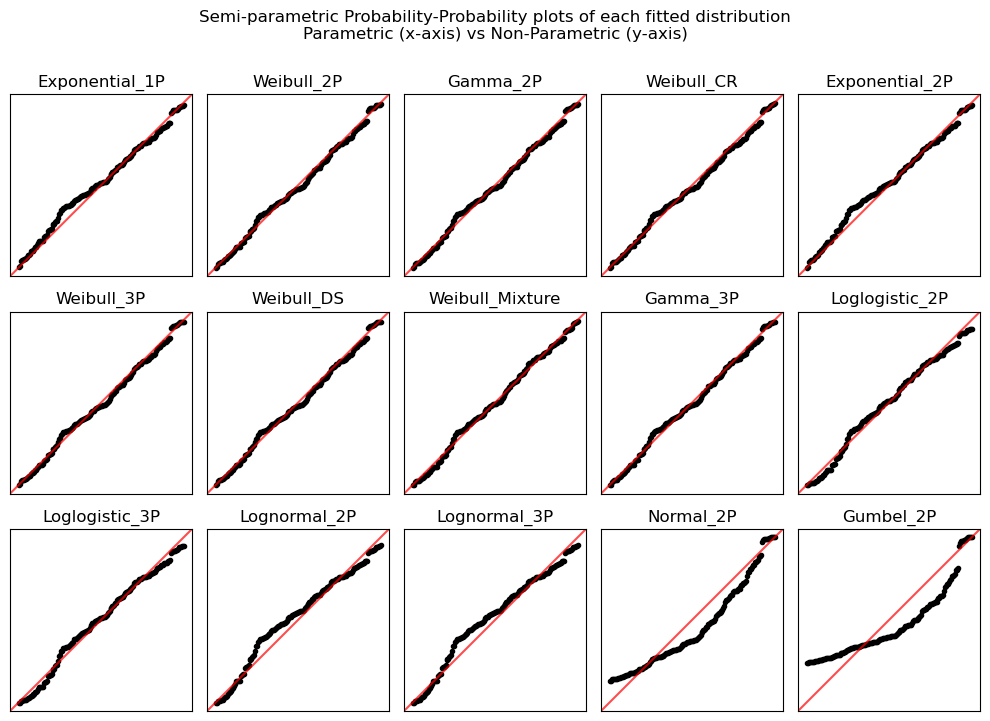

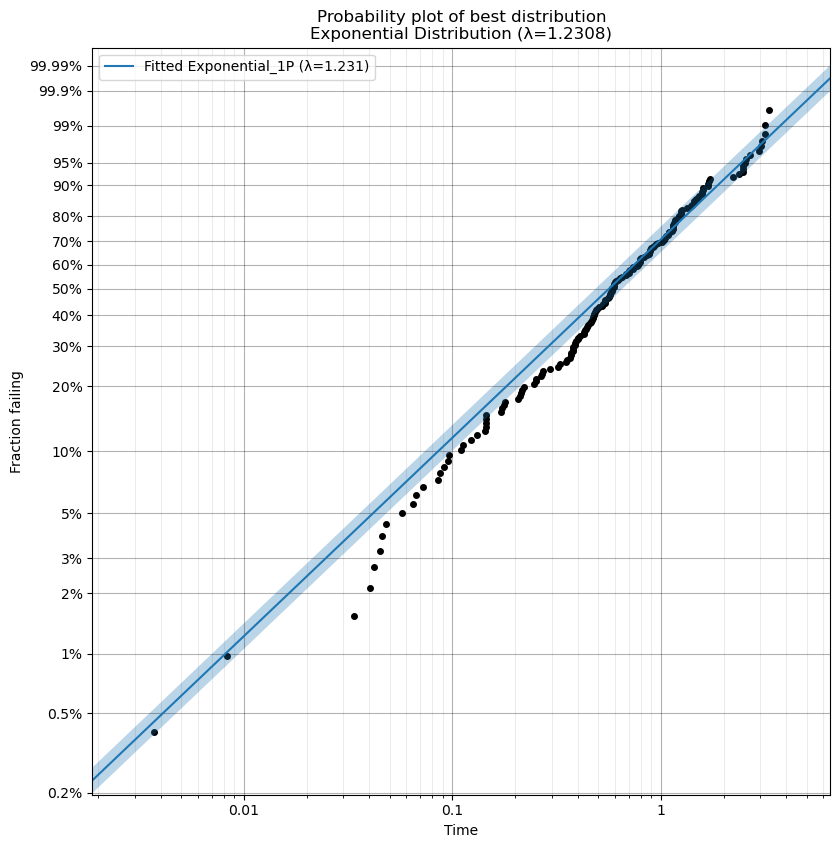

In [53]:
results_bay = rf.Fit_Everything(
    failures=dfmax,
    show_histogram_plot=True,
    show_probability_plot=False,
    print_results=True
)

0.999579883482916
Results from Fit_Exponential_1P (95% CI):
Analysis method: Maximum Likelihood Estimation (MLE)
Optimizer: TNC
Failures / Right censored: 174/0 (0% right censored) 

Parameter  Point Estimate  Standard Error  Lower CI  Upper CI
   Lambda         1.23078       0.0933053   1.06084   1.42794
 1/Lambda        0.812492       0.0615949  0.700309  0.942646 

Goodness of fit    Value
 Log-likelihood -137.869
           AICc  277.761
            BIC  280.897
             AD  1.46333 



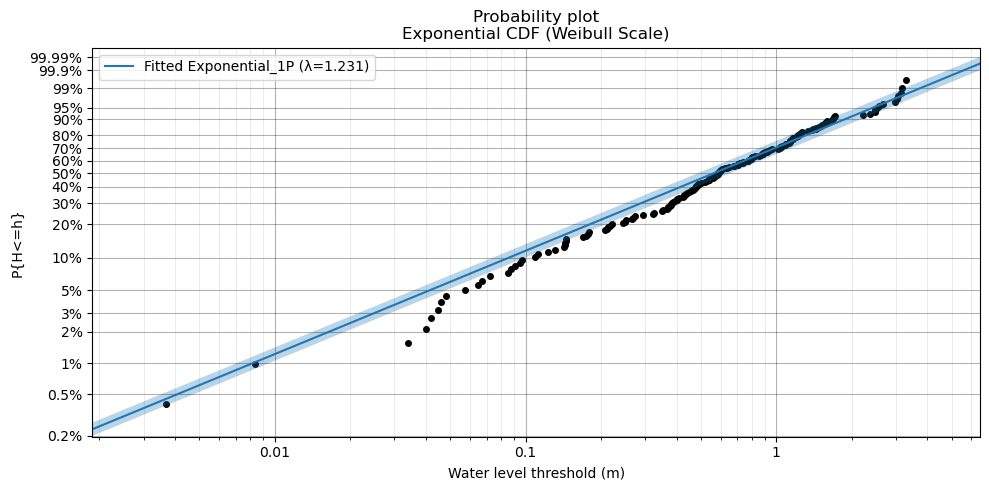

In [54]:
treturn = 1250
numberyears = len(h_sim) / 365
numb = len(pot_maxima) / numberyears
prob = 1 - 1/(numb * treturn)
print(prob)


wae = rf.Fit_Exponential_1P(failures=dfmax)
for num in plt.get_fignums():
    plt.figure(num).set_size_inches(10, 5)
plt.tight_layout()
plt.ylabel('P{H<=h}')
plt.xlabel('Water level threshold (m)')
plt.show()



In [55]:
X_lower,X_point,X_upper = wae.distribution.CDF(CI_y=prob,show_plot=False)
X_point = X_point + tare ## IMP
print('Exponential ',treturn,'Year return value is ',X_point,' (m)')

target_h = 14.8  # Replace with your specific water level (e.g., in cm or m)

excess_h = target_h - tare

prob_exceedance = wae.distribution.SF(excess_h)

calculated_return_period = 1 / (numb * prob_exceedance)

print(f"Water Level: {target_h} m + NAP")
print(f"Corresponding Return Period: {calculated_return_period:.2f} years")

Exponential  1250 Year return value is  14.81710753998417  (m)
Water Level: 14.8 m + NAP
Corresponding Return Period: 1223.96 years
